# RUL-prediksjon – C-MAPSS FD001

Mål: forutsi hvor mange sykluser en motor har igjen før svikt (RUL).

**Innhold**
1. Oppsett
2. Last data og legg til RUL
3. Utforsking
4. Forbehandling
5. Baseline-modell
6. Evaluering

## 1. Oppsett

In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from cmapss.data import load_raw, add_rul

## 2. Last data og legg til RUL

RUL = siste syklus for motoren − nåværende syklus, kuttet ved 125 (se `add_rul` i `cmapss/data.py`).

In [2]:
train = add_rul(load_raw("FD001", "train"))
train.head()

,unit_nr,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,125
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,125
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,125
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,125
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,125


## 3. Utforsking

### 3.1 Sensorer mot RUL

*TODO: diagram #1 – sensorkurver for noen motorer, RUL på x-aksen.*

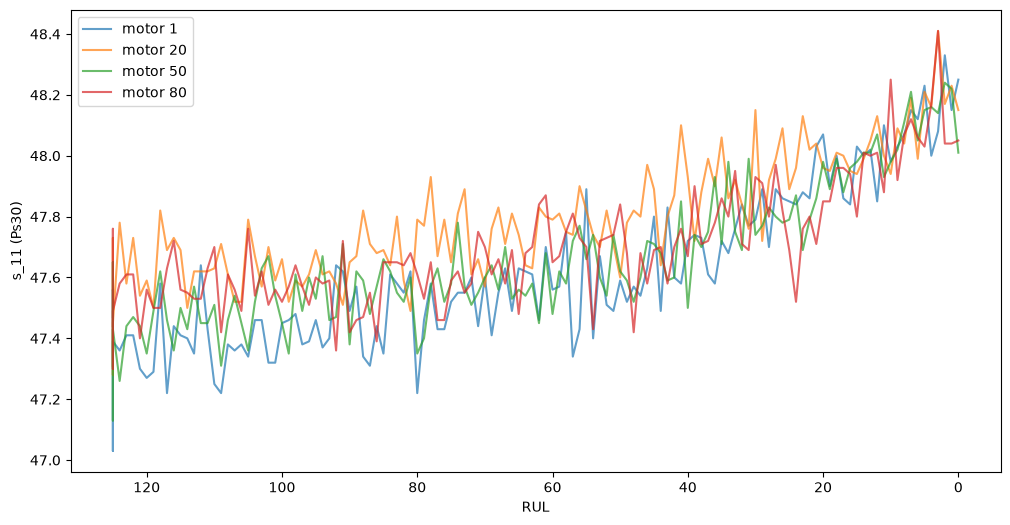

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
for unit in [1, 20, 50, 80]:
    d = train[train.unit_nr == unit]
    ax.plot(d["RUL"], d["s_11"], alpha=0.7, label=f"motor {unit}")
ax.invert_xaxis()          # svikt (RUL=0) til høyre
ax.set_xlabel("RUL"); ax.set_ylabel("s_11 (Ps30)"); ax.legend()


### 3.2 Korrelasjon med RUL

*TODO: diagram #3 – stolpediagram som rangerer sensorene.*

Text(0.5, 1.0, 'Hvilke sensorer følger slitasjen?')

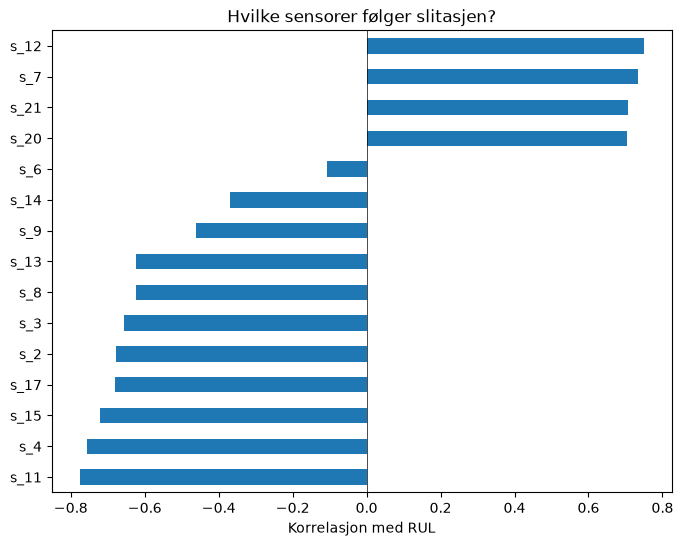

In [6]:
levende = [s for s in sensorer if train[s].std() > 1e-6]   # dropp døde sensorer

corr = train[levende].corrwith(train["RUL"]).sort_values()
corr.plot.barh(figsize=(8, 6))
plt.axvline(0, color="k", lw=0.5)
plt.xlabel("Korrelasjon med RUL")
plt.title("Hvilke sensorer følger slitasjen?")


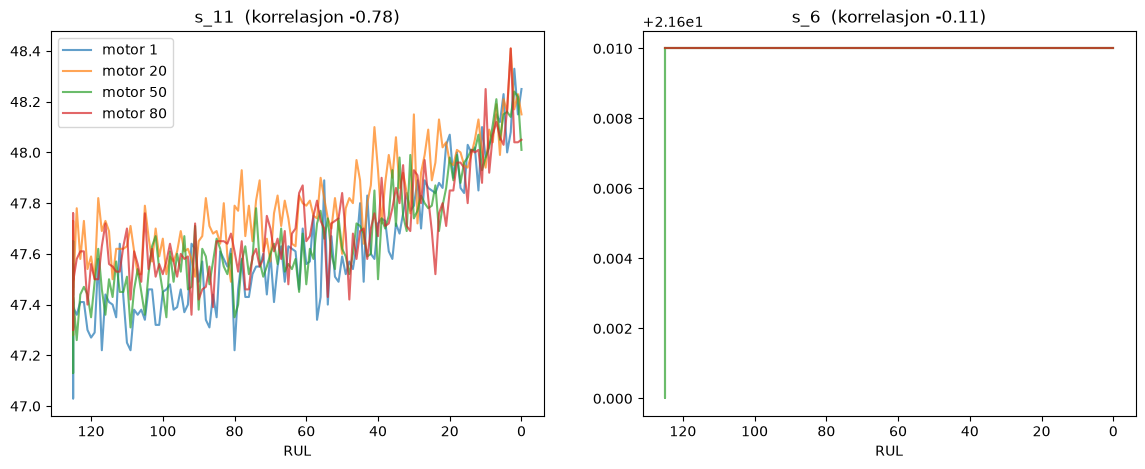

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for ax, s in zip(axes, ["s_11", "s_6"]):
    for unit in [1, 20, 50, 80]:
        d = train[train.unit_nr == unit]
        ax.plot(d["RUL"], d[s], alpha=0.7, label=f"motor {unit}")
    ax.set_title(f"{s}  (korrelasjon {train[s].corr(train['RUL']):.2f})")
    ax.set_xlabel("RUL")
axes[0].invert_xaxis()   # én gang – gjelder begge fordi x-aksen er delt
axes[0].legend()

## 4. Forbehandling

*TODO: fjern døde sensorer og `setting_*`, skaler med `StandardScaler`, split på `unit_nr`.*

In [9]:
features = ["s_2", "s_3", "s_4", "s_7", "s_8", "s_9", "s_11",
            "s_12", "s_13", "s_14", "s_15", "s_17", "s_20", "s_21"]

X = train[features]
y = train["RUL"]

In [11]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, val_idx = next(gss.split(X, y, groups=train["unit_nr"]))

X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

## 5. Baseline-modell

*TODO: `LinearRegression` og `RandomForestRegressor`.*

Stigningstall: 2.5492808329796484
Skjæringspunkt: 3.897707839780294
MSE: 3.4349693170287465
R²: 0.9320077427385524


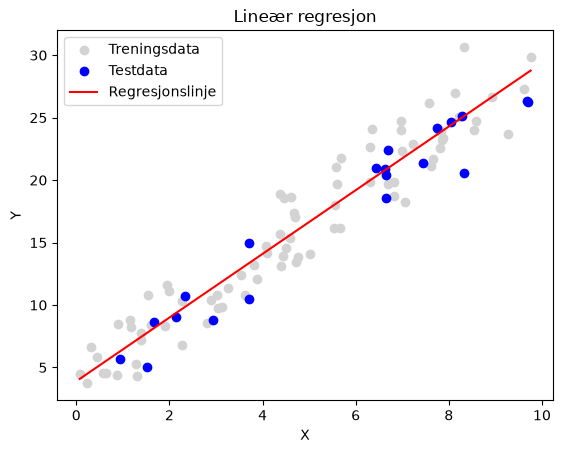

In [12]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Lag eksempeldata med én feature
rng = np.random.default_rng(42)
X = rng.uniform(0, 10, size=(100, 1))
y = 2.5 * X[:, 0] + 4 + rng.normal(0, 2, size=100)

# Del opp i trening og test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Tren modellen
reg = linear_model.LinearRegression()
reg.fit(X_train, y_train)

# Prediker
y_pred = reg.predict(X_test)

# Resultater
print("Stigningstall:", reg.coef_[0])
print("Skjæringspunkt:", reg.intercept_)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Plott
plt.scatter(X_train, y_train, color="lightgray", label="Treningsdata")
plt.scatter(X_test, y_test, color="blue", label="Testdata")

# Sorter for å tegne en pen linje
x_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
plt.plot(x_line, reg.predict(x_line), color="red", label="Regresjonslinje")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Lineær regresjon")
plt.legend()
plt.show()

## 6. Evaluering

*TODO: les testdata + `RUL_FD001.txt`, regn RMSE og NASA-score, plott predikert mot sann RUL.*